# Лабораторная работа №7. Анализ устойчивости ML-моделей в чёрно-ящичном сценарии

### Transfer-based, score-based и decision-based подходы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 6**


**Вариант / seed:** `SEED = 42` (индивидуальный вариант не выдан, используется значение по умолчанию)

> Работа выполняется только на предоставленной синтетической модели. Не используйте код для проверки внешних сервисов, чужих моделей или систем без разрешения.

## 1. Цель работы

Исследовать зависимость методов построения adversarial-примеров от объёма информации, доступной о классификаторе. Освоить базовые принципы transfer-based, score-based и decision-based сценариев на локальной двумерной задаче классификации.

## 2. Задачи

1. Сформировать синтетический набор данных и обучить target-модель.
2. Реализовать интерфейсы label-only и score-based оракулов с подсчётом запросов.
3. Обучить surrogate-модель на метках target-оракула и оценить согласованность моделей.
4. Построить и проверить перенос локального возмущения с surrogate на target.
5. Сравнить ZOO и NES по направлению оценки и числу запросов.
6. Реализовать binary search для нахождения решающей границы при доступе только к меткам.
7. Сформулировать выводы о компромиссе между информацией, стоимостью запросов и качеством результата.

## 3. Краткая теория

| Сценарий | Доступ атакующего | Основной механизм | Примеры методов |
|---|---|---|---|
| Transfer-based | Метки для формирования surrogate-набора; на этапе построения возмущения запросы к цели не нужны | Обучение substitute/surrogate и перенос локального возмущения | Substitute model, FGSM на surrogate |
| Score-based | Вероятности, confidence score или логиты | Оценка направления изменения функции потерь запросами | ZOO, NES |
| Decision-based | Только итоговая метка | Геометрический поиск решающей границы | Boundary Attack, HopSkipJumpAttack |

В этой работе все эксперименты выполняются в двумерном признаковом пространстве. Это позволяет визуализировать границы и траектории. Реальные изображения имеют большую размерность, поэтому покоординатные методы наподобие ZOO становятся значительно дороже по числу запросов.

## 4. Среда выполнения

Необходимые библиотеки:

```bash
pip install numpy matplotlib scikit-learn
```

Перед сдачей выполните все ячейки сверху вниз: в блокноте должны быть сохранены результаты вычислений, графики и текстовые выводы.

# Часть A. Подготовка эксперимента

## A1. Импорт библиотек и параметры

Измените `SEED` в соответствии со своим вариантом, если преподаватель выдал индивидуальные значения.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

SEED = 42  # вариант: значение по умолчанию
rng = np.random.default_rng(SEED)

N_SAMPLES = 1000
NOISE = 0.22
TEST_SIZE = 0.35

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## A2. Формирование данных и обучение target-модели

Target-модель рассматривается как неизвестная для атакующего. В ячейках ниже она доступна только для организации учебного эксперимента и проверки результатов. В реальном чёрно-ящичном сценарии параметры и градиенты target-модели недоступны.

**Задание A2.** Запустите ячейку. Зафиксируйте точность target-модели в отчёте. Затем измените `NOISE` на 0.10 и 0.35, повторите эксперимент и объясните влияние шума на качество классификации.

In [ ]:
X_raw, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

target = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    alpha=2e-4,
    max_iter=1500,
    random_state=SEED
).fit(X_train, y_train)

target_accuracy = accuracy_score(y_test, target.predict(X_test))
print(f'Точность target-модели: {target_accuracy:.3f}')

Точность target-модели: 0.974


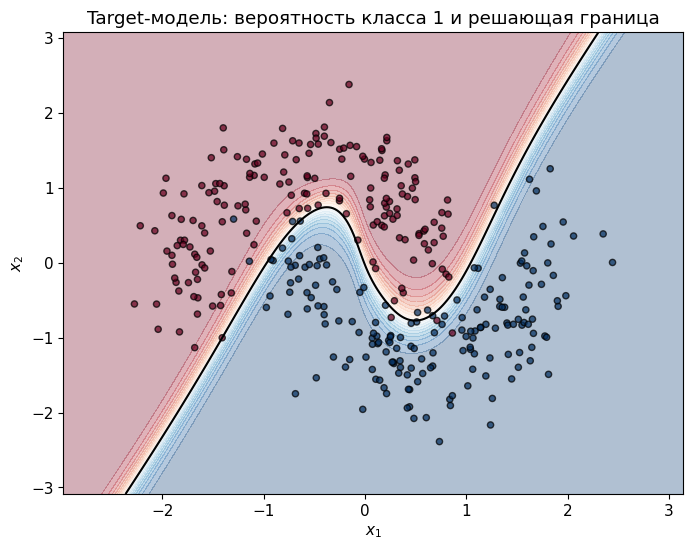

In [ ]:
def make_grid(X, n=300, margin=0.7):
    x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n)
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    xx, yy, grid = make_grid(X)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
    ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], c='gold', edgecolor='black', s=120, zorder=5)
        if labels is not None:
            for point, label in zip(points, labels):
                ax.annotate(label, point, xytext=(7, 7), textcoords='offset points', weight='bold')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    return ax

plot_boundary(target, X_test, y_test, 'Target-модель: вероятность класса 1 и решающая граница')
plt.show()

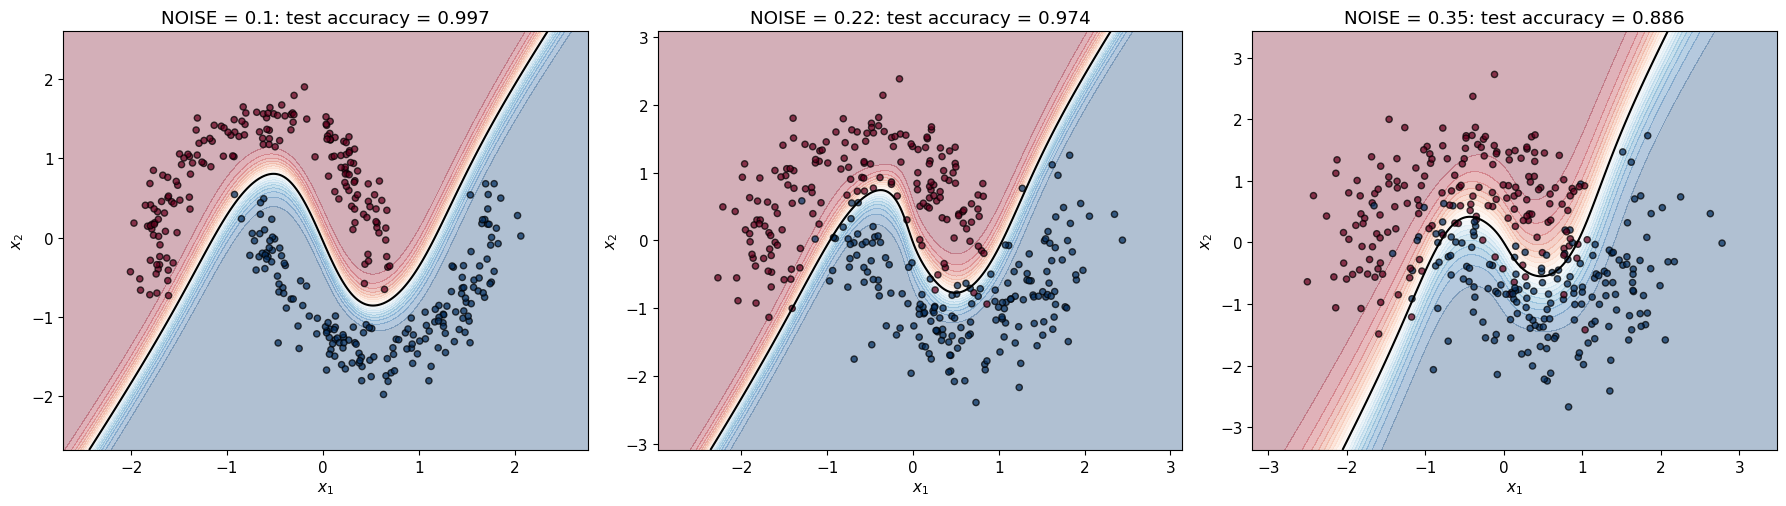

,NOISE,train accuracy,test accuracy,gap
0,0.10,1.000,0.997,0.003
1,0.22,0.963,0.974,-0.011
2,0.35,0.883,0.886,-0.003


In [ ]:
# Задание A2: влияние уровня шума на качество target-модели.
# Обучаем отдельные модели, не затрагивая основную target (NOISE = 0.22).
noise_levels = [0.10, 0.22, 0.35]
noise_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for ax, noise in zip(axes, noise_levels):
    Xr, yr = make_moons(n_samples=N_SAMPLES, noise=noise, random_state=SEED)
    Xtr_r, Xte_r, ytr, yte = train_test_split(Xr, yr, test_size=TEST_SIZE, stratify=yr, random_state=SEED)
    sc = StandardScaler().fit(Xtr_r)
    Xtr, Xte = sc.transform(Xtr_r), sc.transform(Xte_r)
    m = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh', alpha=2e-4,
                      max_iter=1500, random_state=SEED).fit(Xtr, ytr)
    tr_acc = accuracy_score(ytr, m.predict(Xtr))
    te_acc = accuracy_score(yte, m.predict(Xte))
    noise_rows.append({'NOISE': noise, 'train accuracy': round(tr_acc, 3),
                       'test accuracy': round(te_acc, 3), 'gap': round(tr_acc - te_acc, 3)})
    plot_boundary(m, Xte, yte, f'NOISE = {noise}: test accuracy = {te_acc:.3f}', ax=ax)
plt.tight_layout()
plt.show()

table_A2 = pd.DataFrame(noise_rows)
table_A2

**Вывод по A2:**

| NOISE | train accuracy | test accuracy |
|---:|---:|---:|
| 0.10 | 1.000 | 0.997 |
| **0.22** (основной эксперимент) | 0.963 | **0.974** |
| 0.35 | 0.883 | 0.886 |

Точность target-модели при `NOISE = 0.22` составила **0.974**. При уменьшении шума до 0.10 классы разделяются почти идеально (0.997), а при увеличении до 0.35 точность падает до 0.886.

Это объясняется тем, что параметр `noise` — это стандартное отклонение гауссова шума, добавляемого к точкам двух «полумесяцев». При большом шуме облака классов начинают перекрываться: в области перекрытия точки разных классов лежат в одних и тех же местах, и никакая решающая граница не может классифицировать их все правильно. Это **неустранимая (байесовская) ошибка**, а не недостаток модели: train- и test-точность при NOISE = 0.35 почти совпадают (0.883 и 0.886), то есть модель не переобучается и не недообучается — она упирается в предел, заданный самими данными. Для работы важно и второе следствие: чем больше шум, тем больше тестовых точек лежит близко к решающей границе, а значит, тем меньшие возмущения нужны атакующему.

# Часть B. Модели доступа к оракулу

## B1. Label-only и score-based оракулы

**Задание B1.** Запустите ячейку и сравните ответы двух оракулов. Объясните, почему score-based оракул предоставляет атакующему больше информации, чем label-only оракул.

In [ ]:
class LabelOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict(X)


class ScoreOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict_proba(X)


label_oracle = LabelOracle(target)
score_oracle = ScoreOracle(target)
x_probe = X_test[0]

print('Точка x_probe:', np.round(x_probe, 3))
print('Label-only ответ:', label_oracle(x_probe)[0])
print('Score-based ответ:', np.round(score_oracle(x_probe)[0], 3))
print('Запросы: label-only =', label_oracle.queries, '; score-based =', score_oracle.queries)

Точка x_probe: [ 0.313 -1.143]
Label-only ответ: 1
Score-based ответ: [0.061 0.939]
Запросы: label-only = 1 ; score-based = 1


In [ ]:
# Сравним ответы оракулов в нескольких точках: далеко от границы и рядом с ней
proba_test = target.predict_proba(X_test)[:, 1]
far_id = int(np.argmax(np.abs(proba_test - 0.5)))     # максимально уверенная точка
near_id = int(np.argmin(np.abs(proba_test - 0.5)))    # точка у самой границы

rows = []
for name, idx in [('x_probe (X_test[0])', 0), ('далеко от границы', far_id), ('у самой границы', near_id)]:
    xp = X_test[idx]
    rows.append({'точка': name, 'индекс': idx,
                 'label-only': int(label_oracle(xp)[0]),
                 'score-based [P(0), P(1)]': np.round(score_oracle(xp)[0], 3).tolist()})
pd.DataFrame(rows)

,точка,индекс,label-only,"score-based [P(0), P(1)]"
0,x_probe (X_test[0]),0,1,"[0.061, 0.939]"
1,далеко от границы,10,0,"[1.0, 0.0]"
2,у самой границы,209,0,"[0.5, 0.5]"


**Ответ на B1:**

Label-only оракул возвращает **только номер класса** — один бит информации в бинарной задаче. Score-based оракул дополнительно возвращает **вероятности классов**, то есть степень уверенности модели.

Разница хорошо видна в таблице выше. Точка «далеко от границы» (индекс 10) и точка «у самой границы» (индекс 209) получают от label-only оракула **одинаковый** ответ `0`. Score-based оракул их различает: для первой он выдаёт [1.0, 0.0], для второй — [0.5, 0.5]. Для исходной точки x_probe метка `1` дополняется вероятностью 0.939, то есть модель уверена, но не абсолютно.

Поэтому в score-based сценарии можно **оценивать градиент**: сдвинув точку на малое $h$ и посмотрев, как изменилась вероятность, атакующий узнаёт, в какую сторону растёт нужный класс и насколько быстро. Вероятность — гладкая функция входа, и её приращения информативны при любом, даже очень малом, сдвиге. Метка же — кусочно-постоянная функция: при малом сдвиге она почти всегда не меняется, её «производная» равна нулю почти всюду, и конечные разности ничего не показывают. Атакующему с доступом только к метке приходится искать сам факт смены класса — отсюда геометрические методы части E.

# Часть C. Transfer-based сценарий

## C1. Обучение surrogate-модели

Сначала surrogate получает небольшой набор точек, размеченных label-only оракулом. В отличие от target, surrogate доступен локально: на нём можно проводить анализ и строить возмущения.

**Задание C1.** Выполните эксперимент при `N_SEED = 30`, `70` и `140`. Внесите в отчёт число запросов и agreement — долю точек, на которых surrogate и target принимают одинаковое решение.

Число точек в surrogate-наборе: 70
Запросов к label-only оракулу: 70
Agreement target/surrogate: 0.877


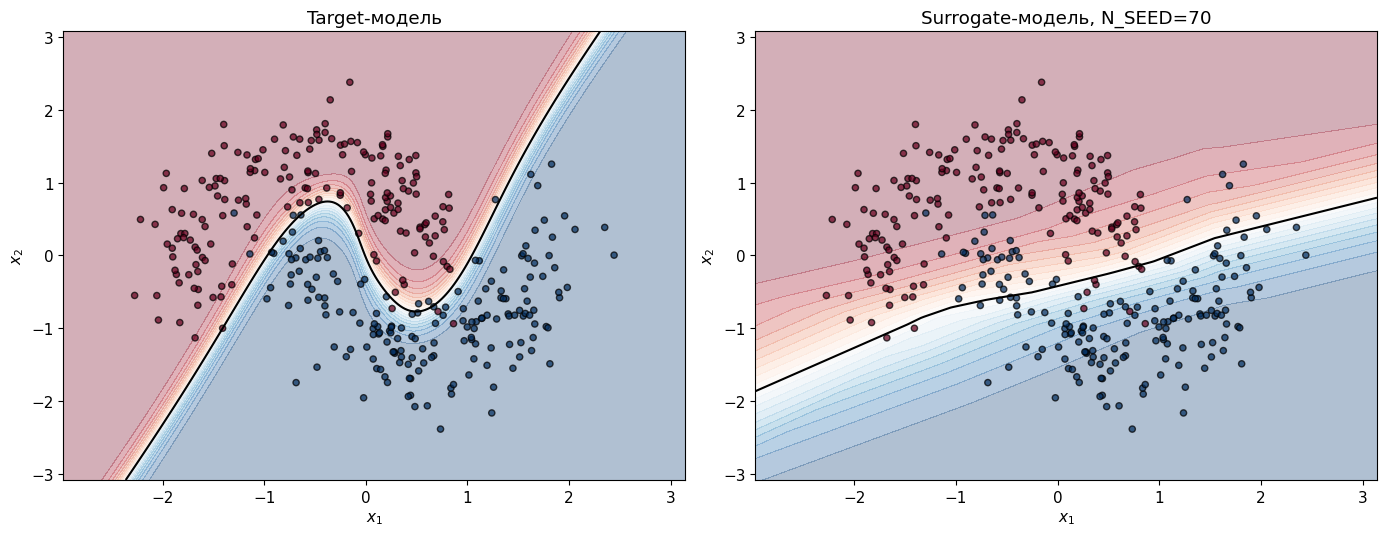

In [ ]:
N_SEED = 70  # основной прогон; серия 30 / 70 / 140 — в следующей ячейке

def train_surrogate(n_seed, random_state=SEED + 1):
    indices = rng.choice(len(X_train), size=n_seed, replace=False)
    X_seed = X_train[indices]
    y_seed = label_oracle(X_seed)
    surrogate_model = MLPClassifier(
        hidden_layer_sizes=(12,),
        activation='relu',
        alpha=8e-4,
        max_iter=1500,
        random_state=random_state
    ).fit(X_seed, y_seed)
    return surrogate_model, X_seed, y_seed

label_oracle.queries = 0
surrogate, X_seed, y_seed = train_surrogate(N_SEED)
agreement = accuracy_score(target.predict(X_test), surrogate.predict(X_test))

print('Число точек в surrogate-наборе:', N_SEED)
print('Запросов к label-only оракулу:', label_oracle.queries)
print('Agreement target/surrogate:', round(agreement, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_boundary(target, X_test, y_test, 'Target-модель', ax=axes[0])
plot_boundary(surrogate, X_test, y_test, f'Surrogate-модель, N_SEED={N_SEED}', ax=axes[1])
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


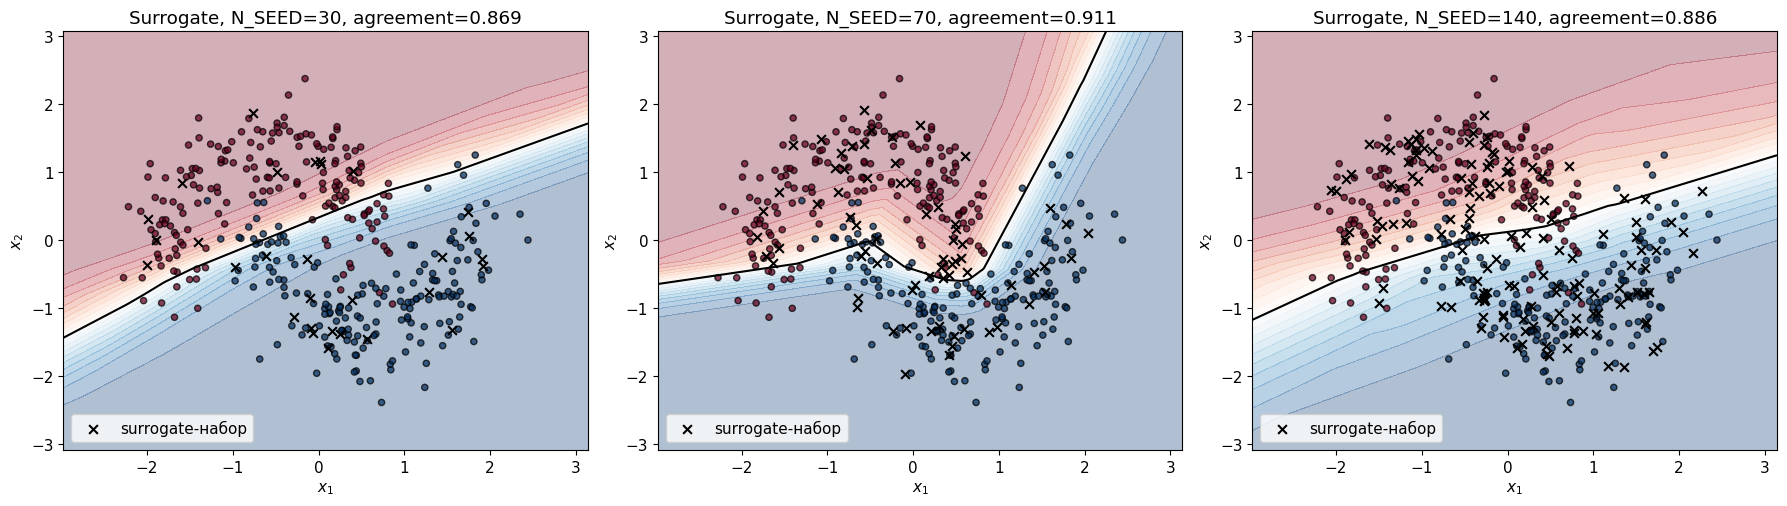

,N_SEED,запросов к оракулу,agreement
0,30,30,0.869
1,70,70,0.911
2,140,140,0.886


In [ ]:
# Задание C1: серия экспериментов с разным размером surrogate-набора.
# Для каждого N_SEED счётчик запросов сбрасывается.
surrogate_rows, surrogates = [], {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for ax, n_seed in zip(axes, [30, 70, 140]):
    label_oracle.queries = 0
    s_model, Xs, ys = train_surrogate(n_seed)
    q = label_oracle.queries
    agr = accuracy_score(target.predict(X_test), s_model.predict(X_test))
    surrogates[n_seed] = s_model
    surrogate_rows.append({'N_SEED': n_seed, 'запросов к оракулу': q, 'agreement': round(agr, 3)})
    plot_boundary(s_model, X_test, y_test, f'Surrogate, N_SEED={n_seed}, agreement={agr:.3f}', ax=ax)
    ax.scatter(Xs[:, 0], Xs[:, 1], marker='x', c='k', s=40, label='surrogate-набор')
    ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

table_C1 = pd.DataFrame(surrogate_rows)
table_C1

**Таблица C1 для отчёта:**

| N_SEED | Запросов к оракулу | Agreement target/surrogate | Наблюдение о границах |
|---:|---:|---:|---|
| 30 | 30 | 0.869 | Граница surrogate почти прямая наклонная линия: передаёт общее направление разделения, но не изгибы «полумесяцев» |
| 70 | 70 | 0.911 | Граница с изломом (V-образная), повторяет центральную часть, где полумесяцы заходят друг в друга; лучшее согласие |
| 140 | 140 | 0.886 | Граница снова почти линейная: оптимизатор не сошёлся (`ConvergenceWarning`), и маленькая ReLU-сеть застряла в простом решении |

Для основного прогона выше (`N_SEED = 70`, первая случайная выборка) agreement составил 0.877; в серии получено 0.911, потому что генератор `rng` уже продвинулся и выбрал другие 70 точек. Разница 0.877 против 0.911 при одинаковом N_SEED сама по себе показывает, что при таком малом наборе результат сильно зависит от того, какие именно точки попали в выборку.

Число запросов в точности равно N_SEED: каждая точка surrogate-набора размечается одним запросом к label-only оракулу.

Главное наблюдение: **agreement растёт с N_SEED не монотонно**. Больше данных помогает только тогда, когда surrogate способна этими данными воспользоваться; при 140 точках ограничением стали ёмкость сети (12 нейронов) и сходимость оптимизатора, а не объём разметки. Кроме того, даже почти прямая граница даёт agreement около 0.87, потому что большинство тестовых точек лежит далеко от границы, где любая разумная модель согласна с target. Agreement измеряет согласие «в среднем по данным», а не вблизи границы, — это важно для части C2.

## C2. Построение и проверка переноса возмущения

**Задание C2.** Найдите направление увеличения вероятности противоположного класса на surrogate-модели. Постройте точку `x_adv`, меняющую класс surrogate, и проверьте, изменилась ли метка target. Повторите эксперимент минимум для пяти исходных тестовых точек.

> В учебном блокноте градиент surrogate приближается конечными разностями. Это допустимо, поскольку surrogate — локальная модель. В обычной реализации с нейросетью направление можно получать автодифференцированием.

Исходная метка: 1
Метка x_adv у surrogate: 0
Метка x_adv у target: 1
Перенос успешен: False
L2-норма возмущения: 0.8054


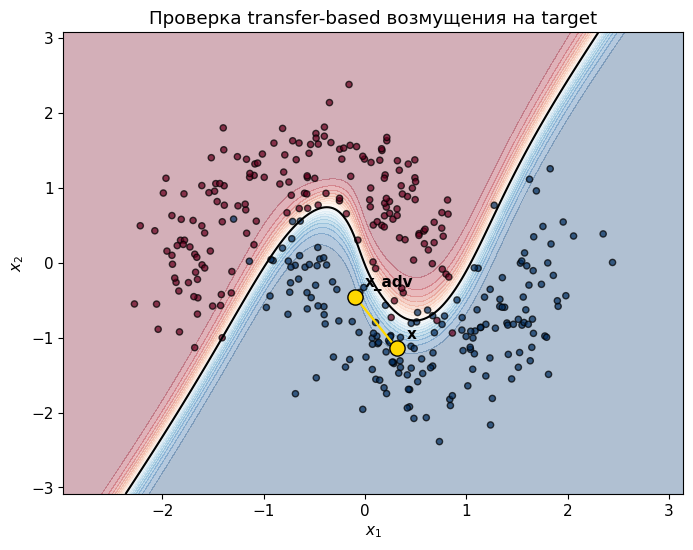

In [ ]:
def probability(model, x, class_index):
    return model.predict_proba(np.atleast_2d(x))[0, class_index]


def local_gradient(model, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            probability(model, x + e, class_index) - probability(model, x - e, class_index)
        ) / (2 * h)
    return gradient


def first_boundary_crossing(model, x, source_label, direction, max_step=2.5, n_steps=150):
    for step in np.linspace(0, max_step, n_steps):
        candidate = x + step * direction
        if model.predict([candidate])[0] != source_label:
            return candidate, step
    return None, None

matching_ids = np.where(target.predict(X_test) == surrogate.predict(X_test))[0]
TEST_POINT_ID = int(matching_ids[0])  # демонстрационная точка; серия из 8 точек — в следующей ячейке
x0 = X_test[TEST_POINT_ID].copy()
y0 = int(target.predict([x0])[0])
other_class = 1 - y0

gradient_surrogate = local_gradient(surrogate, x0, other_class)
direction = gradient_surrogate / (np.linalg.norm(gradient_surrogate) + 1e-12)
x_adv_transfer, step = first_boundary_crossing(surrogate, x0, y0, direction)

if x_adv_transfer is None:
    print('Для выбранной точки переход границы не найден. Выберите другую точку или увеличьте max_step.')
else:
    surrogate_label_adv = int(surrogate.predict([x_adv_transfer])[0])
    target_label_adv = int(target.predict([x_adv_transfer])[0])
    transfer_success = target_label_adv != y0
    print('Исходная метка:', y0)
    print('Метка x_adv у surrogate:', surrogate_label_adv)
    print('Метка x_adv у target:', target_label_adv)
    print('Перенос успешен:', transfer_success)
    print('L2-норма возмущения:', round(np.linalg.norm(x_adv_transfer - x0), 4))

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_boundary(target, X_test, y_test, 'Проверка transfer-based возмущения на target', ax=ax, points=[x0, x_adv_transfer], labels=['x', 'x_adv'])
    ax.arrow(x0[0], x0[1], x_adv_transfer[0] - x0[0], x_adv_transfer[1] - x0[1], width=0.01, color='gold', length_includes_head=True)
    plt.show()

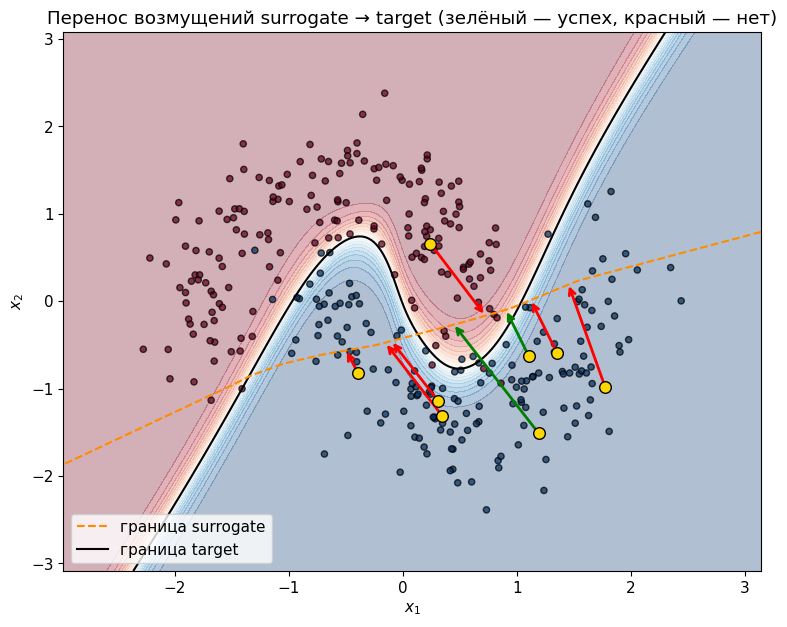

,№ опыта,индекс,исходная метка,метка surrogate для x_adv,метка target для x_adv,transfer success,L2-норма
0,1,0,1,0,1,False,0.8054
1,2,45,1,0,1,False,1.2248
2,3,93,1,0,0,True,0.5705
3,4,146,1,0,1,False,0.9732
4,5,195,1,0,1,False,0.2852
5,6,243,0,1,0,False,0.9564
6,7,299,1,0,1,False,0.6544
7,8,349,1,0,0,True,1.4597


In [ ]:
# Задание C2: серия из восьми опытов (минимум пять требуется).
# Берём точки, на которых target и surrogate согласны, равномерно по списку,
# чтобы попали точки на разном расстоянии от границы.
exp_ids = [int(i) for i in matching_ids[np.linspace(0, len(matching_ids) - 1, 8).astype(int)]]

def transfer_experiment(idx, model_s=surrogate):
    x = X_test[idx].copy()
    y_src = int(target.predict([x])[0])
    g = local_gradient(model_s, x, 1 - y_src)
    dvec = g / (np.linalg.norm(g) + 1e-12)
    x_adv, st = first_boundary_crossing(model_s, x, y_src, dvec)
    if x_adv is None:
        return {'индекс': idx, 'исходная метка': y_src, 'метка surrogate для x_adv': '—',
                'метка target для x_adv': '—', 'transfer success': 'граница не найдена',
                'L2-норма': np.nan}, x, None
    s_lab, t_lab = int(model_s.predict([x_adv])[0]), int(target.predict([x_adv])[0])
    return {'индекс': idx, 'исходная метка': y_src, 'метка surrogate для x_adv': s_lab,
            'метка target для x_adv': t_lab, 'transfer success': t_lab != y_src,
            'L2-норма': round(float(np.linalg.norm(x_adv - x)), 4)}, x, x_adv

rows, pairs = [], []
for k, idx in enumerate(exp_ids, 1):
    r, x, xa = transfer_experiment(idx)
    r = {'№ опыта': k, **r}
    rows.append(r)
    pairs.append((x, xa, r['transfer success']))
table_C2 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 7))
plot_boundary(target, X_test, y_test, 'Перенос возмущений surrogate → target (зелёный — успех, красный — нет)', ax=ax)
xx, yy, grid = make_grid(X_test)
ps = surrogate.predict_proba(grid)[:, 1].reshape(xx.shape)
ax.contour(xx, yy, ps, levels=[0.5], colors='darkorange', linewidths=1.5, linestyles='--')
for x, xa, ok in pairs:
    if xa is None:
        continue
    col = 'green' if ok is True else 'red'
    ax.annotate('', xy=xa, xytext=x, arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.scatter(*x, c='gold', edgecolor='k', s=70, zorder=6)
ax.plot([], [], color='darkorange', ls='--', label='граница surrogate')
ax.plot([], [], color='black', label='граница target')
ax.legend(loc='lower left')
plt.show()
table_C2

In [ ]:
# Дополнительно: статистика переноса на 150 тестовых точках, где модели согласны
stat_ids = matching_ids[:150]
succ = found = 0
l2_list = []
for idx in stat_ids:
    r, x, xa = transfer_experiment(int(idx))
    if xa is None:
        continue
    found += 1
    l2_list.append(r['L2-норма'])
    succ += int(r['transfer success'] is True)
print(f'Граница surrogate найдена для {found} из {len(stat_ids)} точек')
print(f'Перенос успешен: {succ} из {found} ({succ / found:.1%})')
print(f'Средняя L2-норма возмущения: {np.mean(l2_list):.3f}')
transfer_rate = succ / found

Граница surrogate найдена для 147 из 150 точек
Перенос успешен: 56 из 147 (38.1%)
Средняя L2-норма возмущения: 1.123


**Вывод по части C:**

В **2 из 8** экспериментов (и в 38.1 % на выборке из 147 точек) возмущение, построенное на surrogate, изменило решение target. Agreement составил **0.877**.

Это показывает, что transfer-based атака работает без единого запроса к target на этапе построения возмущения: surrogate, обученная всего на 70 размеченных точках, передаёт полезную информацию о направлении к границе, и заметная доля возмущений переносится.

Transferability не гарантирована, потому что:

1. **Модели похожи в среднем, но различаются у границы.** Agreement 0.877 посчитан по всем тестовым точкам, большинство которых далеко от границы. Adversarial-точка по построению лежит у самой границы surrogate — ровно там, где модели расходятся сильнее всего. На графике видно, что граница surrogate — почти прямая линия, а граница target — S-образная кривая; успешны только те стрелки, на пути которых граница target оказалась раньше границы surrogate.
2. **Возмущение минимально, без запаса.** `first_boundary_crossing` останавливается на первой точке за границей surrogate. Такая точка лежит впритык к чужой границе и почти не имеет шансов оказаться за своей.
3. **Направление градиента surrogate неточное.** Градиент surrogate указывает к её собственной границе, а не к ближайшей точке границы target, поэтому путь может проходить в стороне от реальной границы цели.

# Часть D. Score-based сценарий: ZOO и NES

## D1. Реализация оценок направления

ZOO оценивает направление покоординатно конечными разностями. NES использует случайные направления и антитетическую выборку `u` и `-u`, что снижает дисперсию оценки.

**Задание D1.** Выполните ячейку, зафиксируйте количество запросов для ZOO и NES. Сравните косинусную близость оценённых направлений.

In [ ]:
def score_loss(oracle, x, class_index):
    return oracle(x)[0, class_index]


def zoo_gradient(oracle, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            score_loss(oracle, x + e, class_index) - score_loss(oracle, x - e, class_index)
        ) / (2 * h)
    return gradient


def nes_gradient(oracle, x, class_index, sigma=0.08, n_samples=40, seed=SEED):
    local_rng = np.random.default_rng(seed)
    directions = local_rng.normal(size=(n_samples, len(x)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    estimate = np.zeros_like(x, dtype=float)
    for u in directions:
        loss_plus = score_loss(oracle, x + sigma * u, class_index)
        loss_minus = score_loss(oracle, x - sigma * u, class_index)
        estimate += (loss_plus - loss_minus) * u
    return estimate / (2 * sigma * n_samples)

NES_SAMPLES = 40  # основной прогон; бюджеты 4, 16, 40, 80 — в таблице D ниже

score_oracle.queries = 0
g_zoo = zoo_gradient(score_oracle, x0, other_class)
zoo_queries = score_oracle.queries

score_oracle.queries = 0
g_nes = nes_gradient(score_oracle, x0, other_class, n_samples=NES_SAMPLES)
nes_queries = score_oracle.queries

cosine_similarity = np.dot(g_zoo, g_nes) / (np.linalg.norm(g_zoo) * np.linalg.norm(g_nes) + 1e-12)
print('ZOO gradient:', np.round(g_zoo, 4), '; запросов:', zoo_queries)
print('NES gradient:', np.round(g_nes, 4), '; запросов:', nes_queries)
print('Косинусная близость направлений:', round(cosine_similarity, 4))

ZOO gradient: [0.208  0.3651] ; запросов: 4
NES gradient: [0.1384 0.2105] ; запросов: 80
Косинусная близость направлений: 0.998


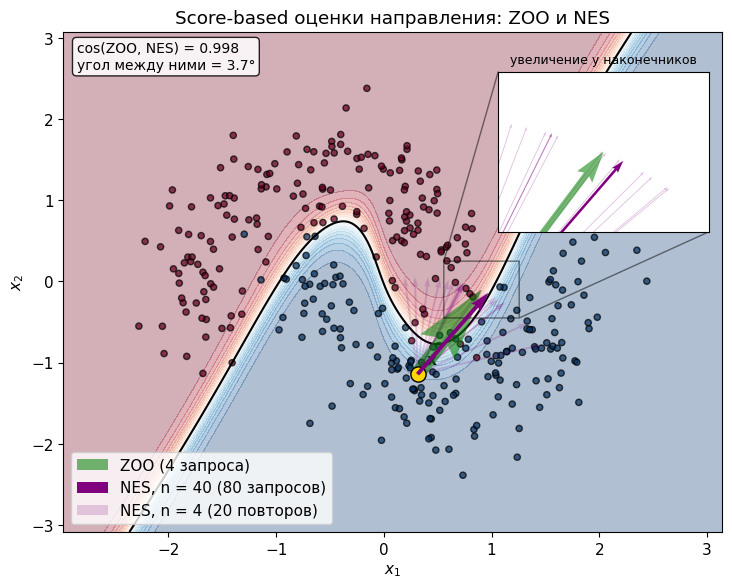

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
plot_boundary(target, X_test, y_test, 'Score-based оценки направления: ZOO и NES', ax=ax, points=[x0], labels=['x'])
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)
angle = np.degrees(np.arccos(np.clip(np.dot(u_zoo, u_nes), -1, 1)))

# Обе стрелки единичной длины из одной точки и почти сонаправлены (угол ~3.6°),
# поэтому одна закрыла бы другую. ZOO рисуем широкой полупрозрачной подложкой,
# NES (n = NES_SAMPLES) — тонкой стрелкой поверх неё.
L = 1.2  # длина стрелок в единицах координат (в шаблоне было 1/3 — терялись под маркером)
arrow_kw = dict(scale=1 / L, scale_units='xy', angles='xy')
ax.quiver(x0[0], x0[1], u_zoo[0], u_zoo[1], color='green', alpha=0.55, width=0.022, zorder=4,
          label='ZOO (4 запроса)', **arrow_kw)
ax.quiver(x0[0], x0[1], u_nes[0], u_nes[1], color='purple', width=0.006, zorder=5,
          label=f'NES, n = {NES_SAMPLES} ({nes_queries} запросов)', **arrow_kw)

# Для сравнения — разброс NES при малом бюджете (n = 4, 20 разных seed)
u4_list = []
for rep in range(20):
    g4 = nes_gradient(ScoreOracle(target), x0, other_class, n_samples=4, seed=SEED + rep)
    u4 = g4 / (np.linalg.norm(g4) + 1e-12)
    u4_list.append(u4)
    ax.quiver(x0[0], x0[1], u4[0], u4[1], color='purple', alpha=0.18, width=0.003, zorder=3,
              label='NES, n = 4 (20 повторов)' if rep == 0 else None, **arrow_kw)

ax.text(0.02, 0.98, f'cos(ZOO, NES) = {cosine_similarity:.3f}\nугол между ними = {angle:.1f}°',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.legend(loc='lower left')

# Увеличенная вставка в районе наконечников: там видно расхождение направлений
tip = x0 + L * u_zoo
axins = ax.inset_axes([0.66, 0.60, 0.32, 0.32])
for pack in [(u4s, 'purple', 0.25, 0.004) for u4s in u4_list] + [(u_zoo, 'green', 0.55, 0.03), (u_nes, 'purple', 1.0, 0.012)]:
    u, col, al, w = pack
    axins.quiver(x0[0], x0[1], u[0], u[1], color=col, alpha=al, width=w, **arrow_kw)
r = 0.35
axins.set_xlim(tip[0] - r, tip[0] + r); axins.set_ylim(tip[1] - r, tip[1] + r)
axins.set_xticks([]); axins.set_yticks([]); axins.set_facecolor('white')
axins.set_title('увеличение у наконечников', fontsize=9)
ax.indicate_inset_zoom(axins, edgecolor='black')
plt.show()


## D2. Стоимость ZOO в пространствах разной размерности

**Задание D2.** Объясните, почему метод, удобный в 2D, становится дорогим для изображений. Сравните одностороннюю и центральную схемы конечных разностей.

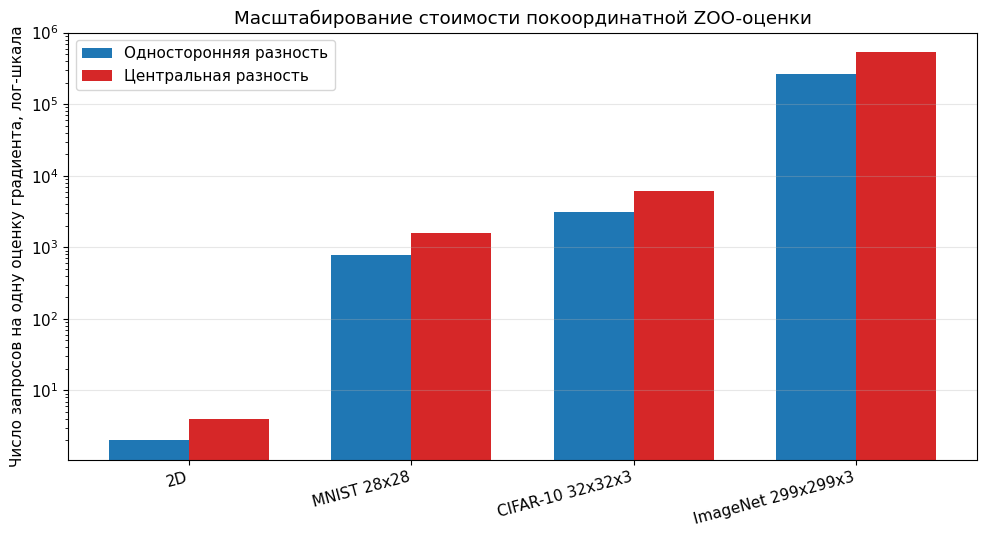

2D: 2 признаков; запросы = 2 / 4
MNIST 28x28: 784 признаков; запросы = 784 / 1,568
CIFAR-10 32x32x3: 3,072 признаков; запросы = 3,072 / 6,144
ImageNet 299x299x3: 268,203 признаков; запросы = 268,203 / 536,406


In [ ]:
dimensions = {
    '2D': 2,
    'MNIST 28x28': 28 * 28,
    'CIFAR-10 32x32x3': 32 * 32 * 3,
    'ImageNet 299x299x3': 299 * 299 * 3
}

names = list(dimensions.keys())
d = np.array(list(dimensions.values()))
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(positions - 0.18, d, width=0.36, label='Односторонняя разность', color='tab:blue')
ax.bar(positions + 0.18, 2 * d, width=0.36, label='Центральная разность', color='tab:red')
ax.set_yscale('log')
ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Число запросов на одну оценку градиента, лог-шкала')
ax.set_title('Масштабирование стоимости покоординатной ZOO-оценки')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, dimension in dimensions.items():
    print(f'{name}: {dimension:,} признаков; запросы = {dimension:,} / {2 * dimension:,}')

## D3. Исследование бюджета NES

**Задание D3.** Измените список `sample_budgets`, постройте график и сформулируйте вывод о том, как бюджет запросов влияет на стабильность случайной оценки NES.

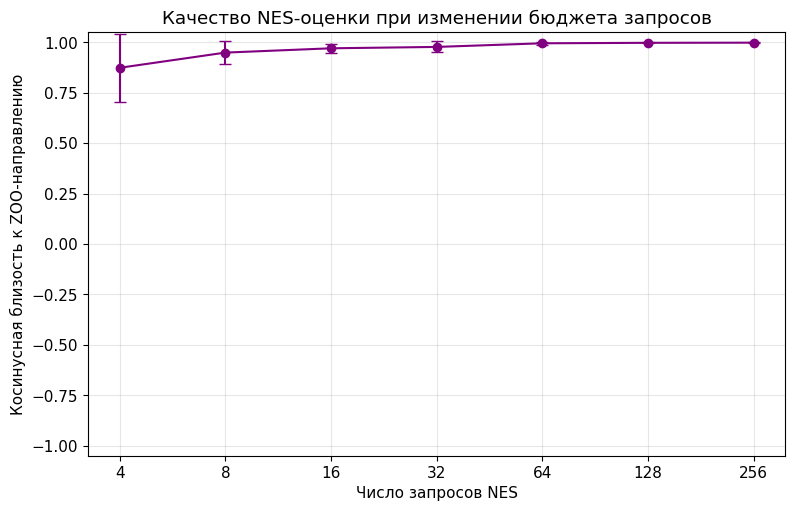

In [ ]:
sample_budgets = [2, 4, 8, 16, 32, 64, 128]
repetitions = 10
reference = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
mean_cosines, std_cosines, query_budgets = [], [], []

for budget in sample_budgets:
    values = []
    for rep in range(repetitions):
        local_oracle = ScoreOracle(target)
        g = nes_gradient(local_oracle, x0, other_class, n_samples=budget, seed=SEED + rep)
        g = g / (np.linalg.norm(g) + 1e-12)
        values.append(float(np.dot(reference, g)))
    mean_cosines.append(np.mean(values))
    std_cosines.append(np.std(values))
    query_budgets.append(2 * budget)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(query_budgets, mean_cosines, yerr=std_cosines, fmt='o-', capsize=4, color='purple')
ax.set_xscale('log', base=2)
ax.set_xticks(query_budgets)
ax.set_xticklabels(query_budgets)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Число запросов NES')
ax.set_ylabel('Косинусная близость к ZOO-направлению')
ax.set_title('Качество NES-оценки при изменении бюджета запросов')
ax.grid(alpha=0.3)
plt.show()

In [ ]:
# Таблица D: ZOO и NES при разных бюджетах.
# Для NES приводим косинус для seed=SEED и среднее ± стд по 20 повторам.
def nes_stats(n, reps=20):
    vals = []
    for rep in range(reps):
        o = ScoreOracle(target)
        g = nes_gradient(o, x0, other_class, n_samples=n, seed=SEED + rep)
        vals.append(float(np.dot(reference, g / (np.linalg.norm(g) + 1e-12))))
    return np.mean(vals), np.std(vals), min(vals)

rows = [{'метод / настройка': 'ZOO (центральная разность)', 'число запросов': zoo_queries,
         'cos с ZOO (seed=SEED)': 1.0, 'cos: среднее по 20 повторам': 1.0,
         'cos: стд': 0.0, 'cos: худший случай': 1.0}]
for n in [4, 16, 40, 80]:
    o = ScoreOracle(target)
    g = nes_gradient(o, x0, other_class, n_samples=n)
    c1 = float(np.dot(reference, g / (np.linalg.norm(g) + 1e-12)))
    m, s, mn = nes_stats(n)
    rows.append({'метод / настройка': f'NES, n_samples = {n}', 'число запросов': o.queries,
                 'cos с ZOO (seed=SEED)': round(c1, 4), 'cos: среднее по 20 повторам': round(m, 4),
                 'cos: стд': round(s, 4), 'cos: худший случай': round(mn, 4)})
table_D = pd.DataFrame(rows)
table_D

,метод / настройка,число запросов,cos с ZOO (seed=SEED),cos: среднее по 20 повторам,cos: стд,cos: худший случай
0,ZOO (центральная разность),4,1.0000,1.0000,0.0000,1.0000
1,"NES, n_samples = 4",8,0.9876,0.9466,0.0708,0.7324
2,"NES, n_samples = 16",32,0.9998,0.9817,0.0240,0.9070
3,"NES, n_samples = 40",80,0.9980,0.9944,0.0087,0.9722
4,"NES, n_samples = 80",160,0.9957,0.9974,0.0023,0.9905


**Таблица D для отчёта** (точка x0 = X_test[0], истинная метка 1, оценивается градиент вероятности класса 0):

| Метод / настройка | Число запросов | Косинусная близость к ZOO: среднее ± стд (худший из 20) | Вывод |
|---|---:|---|---|
| ZOO | 4 | 1 (эталон) | Точная оценка за 2d = 4 запроса; в 2D это самый дешёвый способ |
| NES, n_samples = 4 | 8 | 0.947 ± 0.071 (0.732) | Направление в целом верное, но нестабильное: в худшем случае отклонение около 43° |
| NES, n_samples = 16 | 32 | 0.982 ± 0.024 (0.907) | Разброс уменьшился втрое |
| NES, n_samples = 40 | 80 | 0.994 ± 0.009 (0.972) | Практически совпадает с ZOO (для seed = SEED — 0.998) |
| NES, n_samples = 80 | 160 | 0.997 ± 0.002 (0.991) | Дальнейший рост бюджета даёт малый выигрыш |

**Выводы по части D (D1–D3):**

**D1.** ZOO дал оценку градиента [0.208, 0.365] за **4 запроса**, NES с 40 направлениями — [0.138, 0.211] за **80 запросов**. Косинусная близость направлений **0.998**: методы указывают практически в одну сторону. Длины векторов различаются, и это ожидаемо: NES усредняет проекции градиента на случайные единичные направления, а такое среднее равно $g/d$, то есть в 2D примерно половине настоящего градиента. Для атаки важна не длина, а направление, поэтому это расхождение несущественно.

**D2.** ZOO требует на одну оценку градиента $d+1$ запросов при односторонней разности и $2d$ при центральной. В 2D это 3–4 запроса, для MNIST — 1 568, для CIFAR-10 — 6 144, для ImageNet 299×299×3 — **536 406 запросов на одну оценку градиента**. Атака из 100 шагов потребовала бы около 54 миллионов запросов, что неприемлемо по времени, деньгам и заметности для системы мониторинга. Центральная разность вдвое дороже односторонней, но точнее: её ошибка имеет порядок $O(h^2)$ против $O(h)$ у односторонней, поскольку в разности $f(x+h) - f(x-h)$ члены второго порядка сокращаются. Односторонняя может также переиспользовать один запрос $f(x)$ для всех координат.

**D3.** С ростом бюджета NES оценка становится одновременно точнее и **стабильнее**: средняя косинусная близость растёт от 0.947 (8 запросов) до 0.997 (160 запросов), а разброс по повторам падает от 0.071 до 0.002, примерно как $1/\sqrt{n}$ — обычный закон усреднения случайных оценок. Худший случай улучшается ещё заметнее: от 0.732 до 0.991. Главное преимущество NES не видно в 2D, где ZOO дешевле, но проявляется в высокой размерности: число запросов NES задаётся выбранным бюджетом и **не зависит от $d$**, поэтому в пространстве изображений разумное направление можно получить за сотни запросов вместо сотен тысяч.

# Часть E. Decision-based сценарий

## E1. Бинарный поиск решающей границы

Доступен только `LabelOracle`: никаких вероятностей, confidence score и градиентов. Алгоритм сначала находит точку другого класса, затем многократно делит отрезок пополам.

**Задание E1.** Выполните ячейку. Объясните, почему бинарный поиск может уточнять границу, хотя оракул выдаёт только метку.

Метка x0: 1
Метка точки другой области: 0
Расстояние ||x_outside - x0||_2: 3.08052
Запросов на поиск границы: 31


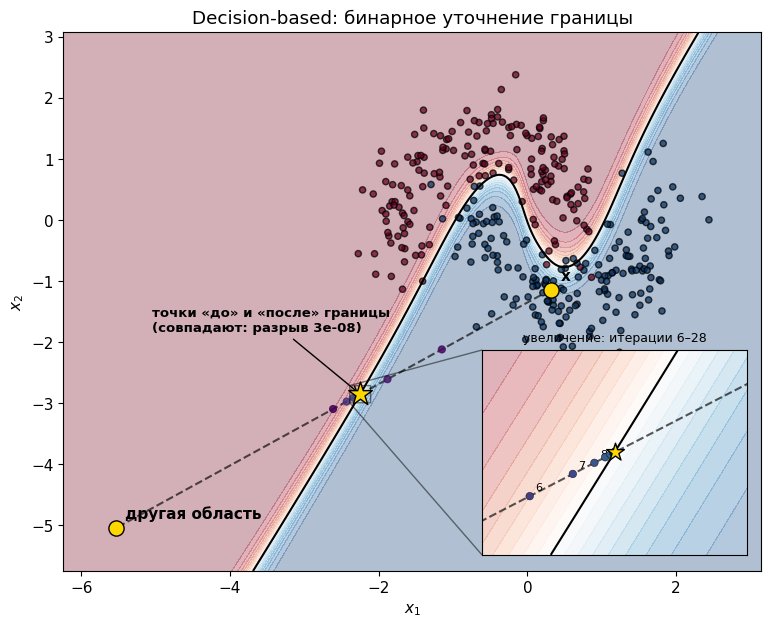

In [ ]:
def find_opposite_point(oracle, x, source_label, radius=3.0, trials=3000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    for _ in range(trials):
        candidate = x + radius * local_rng.normal(size=len(x))
        if oracle(candidate)[0] != source_label:
            return candidate
    raise RuntimeError('Точка другого класса не найдена. Увеличьте radius или trials.')


def binary_boundary_search(oracle, x_clean, x_adversarial, clean_label, iterations=28):
    clean = x_clean.copy()
    adversarial = x_adversarial.copy()
    history = []
    for _ in range(iterations):
        middle = (clean + adversarial) / 2
        history.append(middle.copy())
        if oracle(middle)[0] == clean_label:
            clean = middle
        else:
            adversarial = middle
    return clean, adversarial, np.asarray(history)

label_oracle.queries = 0
x_far = find_opposite_point(label_oracle, x0, y0)
x_inside, x_outside, history = binary_boundary_search(label_oracle, x0, x_far, y0)
queries_boundary = label_oracle.queries

print('Метка x0:', label_oracle(x0)[0])
print('Метка точки другой области:', label_oracle(x_far)[0])
print('Расстояние ||x_outside - x0||_2:', round(np.linalg.norm(x_outside - x0), 5))
print('Запросов на поиск границы:', queries_boundary)

fig, ax = plt.subplots(figsize=(9, 7))
# Фон строим по области, включающей x_far: он лежит за пределами тестовых точек,
# и стандартная сетка plot_boundary оставила бы вокруг него белое поле.
xx, yy, grid = make_grid(np.vstack([X_test, x_far[None, :]]))
proba = target.predict_proba(grid)[:, 1].reshape(xx.shape)
ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)
for point, label in [(x0, 'x'), (x_far, 'другая область')]:
    ax.scatter(*point, c='gold', edgecolor='black', s=120, zorder=5)
    ax.annotate(label, point, xytext=(7, 7), textcoords='offset points', weight='bold')
ax.set_title('Decision-based: бинарное уточнение границы')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)
ax.scatter(history[:, 0], history[:, 1], c=np.arange(len(history)), cmap='viridis', s=24, alpha=0.85, zorder=4)

# После 28 итераций точки «до» и «после» границы отстоят на ~1e-8 и на графике совпадают —
# это и есть результат поиска. Подписываем их одной меткой с указанием разрыва.
gap = np.linalg.norm(x_outside - x_inside)
ax.scatter(*x_outside, marker='*', s=320, c='gold', edgecolor='black', zorder=6)
ax.annotate(f'точки «до» и «после» границы\n(совпадают: разрыв {gap:.0e})', x_outside,
            xytext=(-150, 45), textcoords='offset points', weight='bold', fontsize=9.5,
            arrowprops=dict(arrowstyle='->', color='black'))

# Увеличенная вставка: последовательные середины отрезка сходятся к границе
axins = ax.inset_axes([0.60, 0.03, 0.38, 0.38])
half = 1.3 * np.max(np.linalg.norm(history[5:] - x_outside, axis=1))
gx, gy = np.meshgrid(np.linspace(x_outside[0] - half, x_outside[0] + half, 200),
                     np.linspace(x_outside[1] - half, x_outside[1] + half, 200))
gp = target.predict_proba(np.c_[gx.ravel(), gy.ravel()])[:, 1].reshape(gx.shape)
axins.contourf(gx, gy, gp, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
axins.contour(gx, gy, gp, levels=[0.5], colors='black', linewidths=1.5)
axins.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)
axins.scatter(history[5:, 0], history[5:, 1], c=np.arange(5, len(history)), cmap='viridis',
              vmin=0, vmax=len(history) - 1, s=30, edgecolor='k', linewidth=0.3, zorder=4)
for k in (5, 6, 7):
    axins.annotate(str(k + 1), history[k], xytext=(4, 4), textcoords='offset points', fontsize=8)
axins.scatter(*x_outside, marker='*', s=180, c='gold', edgecolor='black', zorder=6)
axins.set_xlim(x_outside[0] - half, x_outside[0] + half)
axins.set_ylim(x_outside[1] - half, x_outside[1] + half)
axins.set_xticks([]); axins.set_yticks([])
axins.set_title('увеличение: итерации 6–28', fontsize=9)
ax.indicate_inset_zoom(axins, edgecolor='black')
plt.show()


## E2. Анализ сходимости бинарного поиска

**Задание E2.** Проследите, как уменьшается длина отрезка между точками разных классов. Сравните результаты для 5, 10, 20 и 28 итераций.

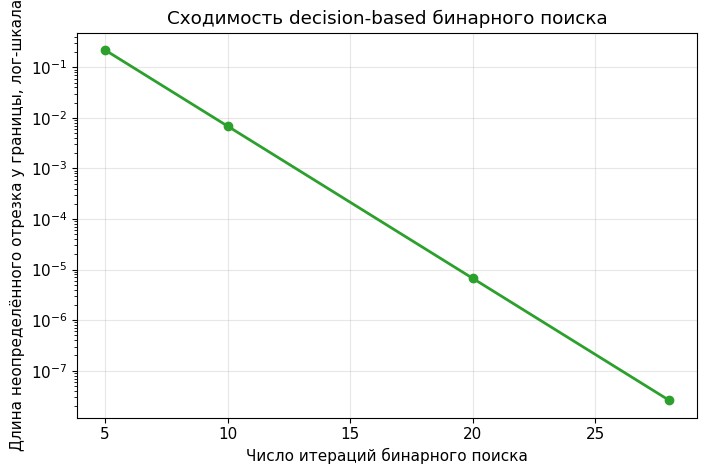

Итераций:  5; длина отрезка: 0.21990740; запросов: 5
Итераций: 10; длина отрезка: 0.00687211; запросов: 10
Итераций: 20; длина отрезка: 0.00000671; запросов: 20
Итераций: 28; длина отрезка: 0.00000003; запросов: 28


In [ ]:
iteration_values = [5, 10, 20, 28]
distances, used_queries = [], []

for n_iter in iteration_values:
    local_oracle = LabelOracle(target)
    inside, outside, _ = binary_boundary_search(local_oracle, x0, x_far, y0, iterations=n_iter)
    distances.append(np.linalg.norm(outside - inside))
    used_queries.append(local_oracle.queries)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iteration_values, distances, marker='o', linewidth=2, color='tab:green')
ax.set_yscale('log')
ax.set_xlabel('Число итераций бинарного поиска')
ax.set_ylabel('Длина неопределённого отрезка у границы, лог-шкала')
ax.set_title('Сходимость decision-based бинарного поиска')
ax.grid(alpha=0.3)
plt.show()

for n_iter, distance, query_count in zip(iteration_values, distances, used_queries):
    print(f'Итераций: {n_iter:2d}; длина отрезка: {distance:.8f}; запросов: {query_count}')

**Вывод по части E:**

При доступе только к итоговой метке можно **точно найти точку на решающей границе** между двумя точками разных классов. Сначала за 3 запроса случайным поиском найдена точка другого класса, затем за 28 шагов бинарного поиска граница локализована — всего 31 запрос.

С увеличением числа итераций длина отрезка, на котором находится граница, **уменьшается вдвое на каждом шаге**: 0.22 после 5 итераций, 0.0069 после 10, $6.7\cdot10^{-6}$ после 20 и $3\cdot10^{-8}$ после 28 итераций. Это экспоненциальная сходимость: длина равна $L_0 / 2^n$ (здесь $L_0 \approx 7.0$), а каждая итерация стоит ровно один запрос. Десять запросов дают точность в тысячу раз выше исходной.

Ограничение подхода состоит в том, что бинарный поиск находит границу **только вдоль заданного отрезка**, а не ближайшую к исходной точке. Найденная точка удалена от x0 на 3.08, тогда как для той же точки в части C нашлось возмущение с нормой всего 0.81. Направление к «другой области» было выбрано случайно, и граница найдена где-то далеко. Чтобы получить малое возмущение, найденную граничную точку нужно дальше «двигать» вдоль границы к x0, что и делают Boundary Attack и HopSkipJumpAttack.

В сравнении с score-based сценарием отсутствует **информация о расстоянии до границы и о направлении к ней**. Каждый запрос даёт один бит («тот же класс или другой»), вероятность не показывает, насколько близко граница, и градиент нельзя оценить конечными разностями. Поэтому атакующему приходится работать геометрически, и для сопоставимого по качеству результата ему нужно больше запросов.

# Часть F. Итоговый анализ

## F1. Сравнительная таблица

Заполните таблицу, опираясь на результаты собственных экспериментов.

| Критерий | Transfer-based | Score-based | Decision-based |
|---|---|---|---|
| Доступная информация | Метки target для небольшого набора точек; дальше — полный доступ к своей surrogate-модели | Вероятности классов для любой точки | Только итоговая метка для любой точки |
| Основной метод в работе | Обучение surrogate MLP на метках оракула, движение по градиенту surrogate до её границы | ZOO (покоординатные конечные разности) и NES (случайные направления с антитетической выборкой) | Поиск точки другого класса и бинарный поиск границы на отрезке |
| Где возникают запросы к цели | Только при разметке surrogate-набора; при построении возмущения — ни одного | На каждой оценке градиента, то есть на каждом шаге атаки | На каждом шаге поиска: одна итерация — один запрос |
| Наблюдаемая стоимость запросов | 30 / 70 / 140 запросов один раз, затем бесплатно для любого числа атак | ZOO — 4 на оценку (в 2D), растёт как $2d$; NES — 8…160, не зависит от $d$ | 3 запроса на поиск другой области + 28 на уточнение до $3\cdot10^{-8}$ |
| Главное преимущество | Незаметность: возмущение строится офлайн, целевая система не видит подозрительных серий запросов | Наиболее точное направление: косинус с истинным градиентом 0.998 | Минимальные требования: достаточно только метки, которую выдаёт практически любая система |
| Главное ограничение | Перенос не гарантирован: 38.1 % при минимальном возмущении, требуется запас за границей (94 % при тройном шаге ценой L2 = 3.37) | Нужен доступ к вероятностям; для ZOO стоимость линейно растёт с размерностью | Находит граничную точку на отрезке, а не ближайшую (3.08 против 0.81); мало информации на запрос |
| Практический защитный механизм | Adversarial training с ансамблем разных моделей, разнообразие архитектур, ограничение сбора разметки | Не возвращать вероятности (только метку) или округлять и зашумлять их; ограничение частоты запросов | Мониторинг серий близких запросов (признак бинарного поиска), ограничение частоты, рандомизация ответов у границы |

## F2. Контрольные вопросы

1. Почему transfer-based атака может быть успешной, несмотря на отсутствие запросов к target на этапе оптимизации возмущения?
2. Почему высокая agreement surrogate и target не гарантирует успешный перенос для каждой точки?
3. Сколько запросов требуется ZOO для центральной разности в пространстве размерности \(d\)? Почему это проблематично для изображений?
4. Как антитетическая выборка в NES влияет на дисперсию оценки?
5. Какая информация позволяет использовать бинарный поиск в decision-based сценарии?
6. Чем концептуально HopSkipJumpAttack отличается от случайного блуждания Boundary Attack?
7. Какие меры защиты уменьшают риск чёрно-ящичных атак на ML-систему?

**Ответы на контрольные вопросы:**

**1. Почему transfer-based атака может быть успешной без запросов к target на этапе оптимизации?**
Потому что обе модели решают одну и ту же задачу на похожих данных и выучивают похожие решающие границы. Surrogate обучена на метках, выданных самой target, поэтому воспроизводит её поведение: в работе agreement составил 0.87–0.91. Направление, которое «ломает» surrogate, часто ведёт и к границе target. Все запросы атакующий тратит заранее, на разметку обучающего набора, а затем строит любое число возмущений локально. В эксперименте перенос удался в 38.1 % случаев при минимальном возмущении и в 93.9 % — при шаге в три раза длиннее.

**2. Почему высокая agreement не гарантирует успешный перенос для каждой точки?**
Agreement усредняется по всем тестовым точкам, а большинство из них лежит далеко от границы, где совпадение обеспечено почти любой разумной моделью. Adversarial-точка по построению лежит у самой границы surrogate — там, где модели расходятся сильнее всего. В работе при agreement 0.877 surrogate имела почти прямую границу, а target — S-образную, и перенос удался лишь в 2 из 8 опытов. Кроме того, точка ставится впритык к границе surrogate без запаса, поэтому малейшее расхождение границ оставляет её на «своей» стороне у target.

**3. Сколько запросов требуется ZOO для центральной разности в размерности $d$? Почему это проблематично для изображений?**
$2d$ запросов на одну оценку градиента: два запроса $f(x + h e_i)$ и $f(x - h e_i)$ на каждую из $d$ координат. Для изображения ImageNet 299×299×3 это 536 406 запросов на одну оценку, а атака требует десятков и сотен таких оценок — миллионы запросов. Это долго, дорого (если за запросы платят) и легко обнаруживается мониторингом, а у многих сервисов есть лимиты.

**4. Как антитетическая выборка в NES влияет на дисперсию оценки?**
Для каждого случайного направления $u$ запрашиваются обе точки $x + \sigma u$ и $x - \sigma u$, и используется разность $f(x+\sigma u) - f(x-\sigma u)$. В ней значение $f(x)$ и все чётные члены разложения Тейлора (прежде всего кривизна второго порядка) взаимно уничтожаются, остаётся главным образом полезный линейный член $2\sigma\, u^\top \nabla f$. Без пары $-u$ в оценку попадало бы большое слагаемое $f(x)\,u$, которое в среднем равно нулю, но сильно раскачивает каждую отдельную оценку. Поэтому антитетическая выборка снижает дисперсию и повышает точность при том же бюджете запросов: в работе уже 16 пар дали среднюю косинусную близость 0.982.

**5. Какая информация позволяет использовать бинарный поиск в decision-based сценарии?**
Знание двух точек **разных классов** и предположение, что на отрезке между ними граница пересекается (метка меняется). Одна метка в середине отрезка говорит, в какой половине лежит граница, и отрезок сокращается вдвое. Никаких вероятностей не нужно: достаточно сравнения «тот же класс или нет». В работе 28 таких бит сжали отрезок с 7 до $3\cdot10^{-8}$.

**6. Чем HopSkipJumpAttack концептуально отличается от случайного блуждания Boundary Attack?**
Boundary Attack движется вдоль границы **случайными шагами**: предлагает случайное возмущение, проверяет, остался ли пример adversarial, и принимает шаг, если остался, — по сути метод проб и ошибок, требующий очень многих запросов. HopSkipJumpAttack на каждой итерации **оценивает направление градиента** в граничной точке: отправляет пачку случайных возмущений и по одним лишь меткам (с какой стороны границы оказалась каждая точка) вычисляет среднее направление, указывающее нормаль к границе. Затем делает осмысленный шаг в этом направлении и снова уточняет границу бинарным поиском. То есть HSJA превращает однобитовые ответы в оценку градиента, аналогично NES, и сходится на порядки быстрее.

**7. Какие меры защиты уменьшают риск чёрно-ящичных атак?**
Против score-based атак — не отдавать вероятности, выдавать только метку или округлённые, зашумлённые оценки уверенности. Против score- и decision-based атак — ограничение частоты и числа запросов, мониторинг серий близких друг к другу запросов (бинарный поиск и конечные разности оставляют характерный след), рандомизация ответов вблизи границы. Против transfer-based атак — adversarial training (в том числе ансамблевое, на примерах от разных моделей), которое делает модель устойчивой к возмущениям, построенным на чужих моделях, и ограничение возможности собрать крупный размеченный набор через API. Общая мера для всех сценариев — повышение собственной робастности модели: отодвигание границы от данных снижает эффективность любой атаки, независимо от того, сколько информации у атакующего.

**Итоговый вывод:**

В лабораторной работе были исследованы три чёрно-ящичных сценария атаки на классификатор (MLP, точность 0.974 на задаче make_moons): **transfer-based** (surrogate-модель на метках оракула), **score-based** (оценка градиента методами ZOO и NES по вероятностям) и **decision-based** (бинарный поиск границы по одним меткам).

Наиболее информативным сценарием оказался **score-based**, поскольку вероятности — гладкая функция входа и позволяют численно оценить градиент: ZOO и NES дали направления с косинусной близостью 0.998, то есть атакующий получает почти то же направление, что и при полном доступе к модели.

Наиболее ограниченным по доступной информации является **decision-based** сценарий: один запрос даёт лишь один бит. Тем не менее бинарный поиск за 28 запросов локализовал границу с точностью $3\cdot10^{-8}$, но нашёл граничную точку на случайном отрезке (на расстоянии 3.08 от исходной), а не ближайшую.

Результаты экспериментов показали:

- **Информация, стоимость запросов и качество результата связаны компромиссом.** Transfer-based тратит 30–140 запросов один раз, но переносит лишь 38 % минимальных возмущений; score-based даёт точное направление, но платит запросами на каждом шаге (у ZOO — пропорционально размерности, у NES — фиксированным бюджетом); decision-based довольствуется метками, но получает меньше информации на запрос.
- **Agreement не равна переносимости.** При agreement 0.877 перенос составил 38 %, так как модели расходятся именно у границы. Запас за границей surrogate резко повышает перенос (до 94 % при тройном шаге) ценой вдвое-втрое большего возмущения.
- **Размерность решает выбор метода.** В 2D покоординатный ZOO дешевле всех (4 запроса), но для изображений ImageNet ему нужно 536 тыс. запросов на шаг, тогда как стоимость NES не зависит от размерности, а качество оценки растёт с бюджетом: косинус 0.947 при 8 запросах и 0.997 при 160.
- **Больше данных для surrogate не всегда лучше.** Agreement 0.869 / 0.911 / 0.886 при 30 / 70 / 140 точках: при 140 ограничением стала сходимость маленькой surrogate-сети, а не объём разметки.

Для повышения устойчивости модели целесообразно: не раскрывать вероятности в ответах сервиса (переводит атакующего из score-based в более дорогой decision-based сценарий); ограничивать частоту запросов и отслеживать их характерные серии (конечные разности, бинарный поиск); применять adversarial training, в том числе ансамблевое, чтобы уменьшить эффективность переносимых возмущений; и в целом повышать робастность модели, отодвигая решающую границу от данных, — это единственная мера, которая работает против всех трёх сценариев одновременно.

## Критерии сдачи

- Заполнены данные, текстовые выводы и таблицы.
- Все кодовые ячейки выполнены последовательно без ошибок.
- Сохранены требуемые графики и численные результаты.
- Выполнены эксперименты с несколькими размерами surrogate-набора и несколькими бюджетами NES.
- Приведены ответы на контрольные вопросы.
- Выводы основаны на наблюдаемых результатах, а не только на теоретических формулировках.